In [47]:
import pandas as pd
from  pathlib import Path

data = Path.cwd()/ "data"/"titanic.csv"
df = pd.read_csv(data)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [49]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [50]:
df.shape

(891, 12)

In [51]:
# df = df[df.Embarked.notna()]
df.dropna(subset=["Embarked"], inplace=True)
# df.info()
df.drop("Cabin", axis=1, inplace=True)
# df.drop(columns=["Cabin"], inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


In [52]:
import matplotlib.pyplot as plt


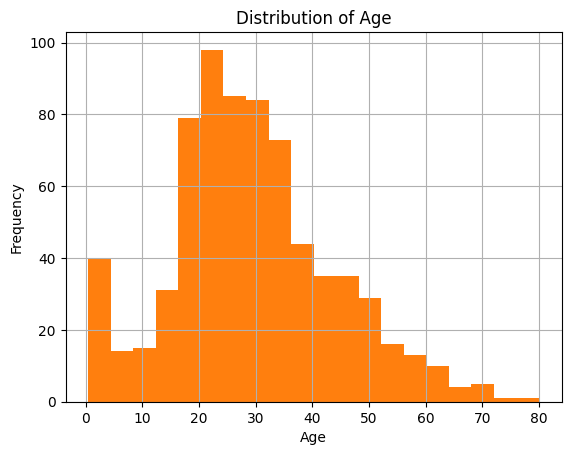

count    712.000000
mean      29.642093
std       14.492933
min        0.420000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [53]:
df["Age"].hist( bins=20)
plt.hist(df["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()
df["Age"].describe()

In [62]:
df_tmp = df.copy()
# df["Age"] = df.loc[df.Age.isna(), "Age"] = 0
df_tmp.fillna(value={"Age": df["Age"].mean()}, inplace=True)
df_tmp.info()
df_tmp.isna().sum().to_frame("count").T



<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
count,0,0,0,0,0,0,0,0,0,0,0


Text(0.5, 1.0, 'Filled Data with Mean')

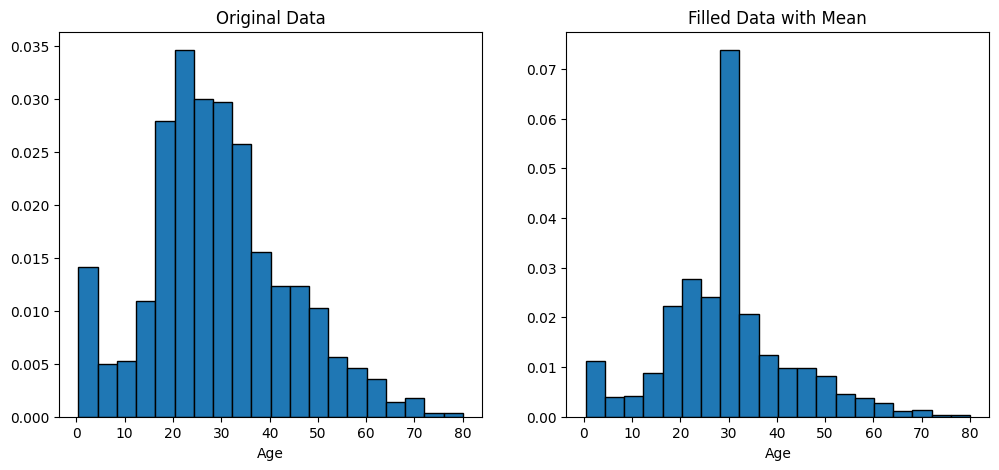

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(df["Age"], bins=20, density=True, edgecolor="black" )
ax[0].set_xlabel("Age")
ax[0].set_title("Original Data")

ax[1].hist(df_tmp["Age"], bins=20, density=True, edgecolor="black" )
ax[1].set_xlabel("Age")
ax[1].set_title("Filled Data with Mean")

# # df.describe()
# df_tmp.describe()

In [68]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,712.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.642093,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,14.492933,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,20.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [69]:
df_tmp.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.642093,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,12.968346,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,29.642093,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Text(0.5, 1.0, 'Filled Data with Mean')

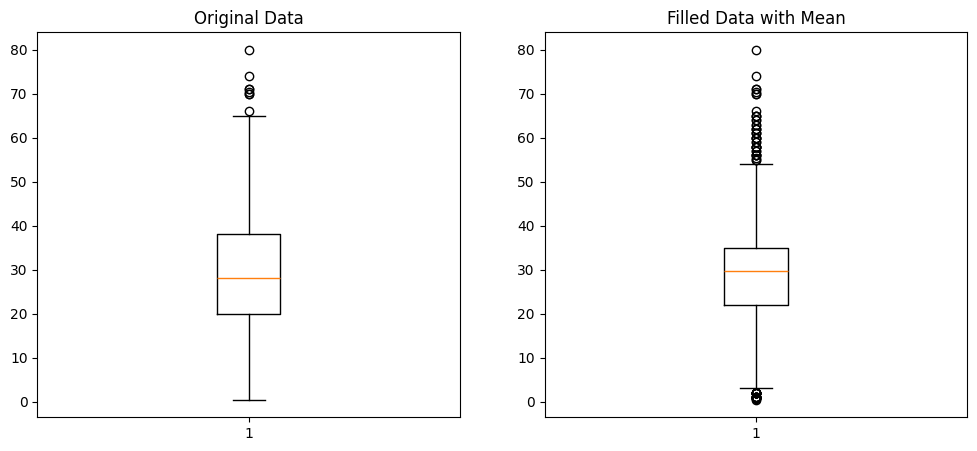

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].boxplot(df["Age"].dropna())
ax[0].set_title("Original Data")    

ax[1].boxplot(df_tmp["Age"])
ax[1].set_title("Filled Data with Mean")

In [78]:
df_tmp = df.copy()
df_tmp["Age"] = df_tmp["Age"].bfill()
df_tmp.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,54.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


Text(0.5, 1.0, 'Filled Data with fillna with bfill')

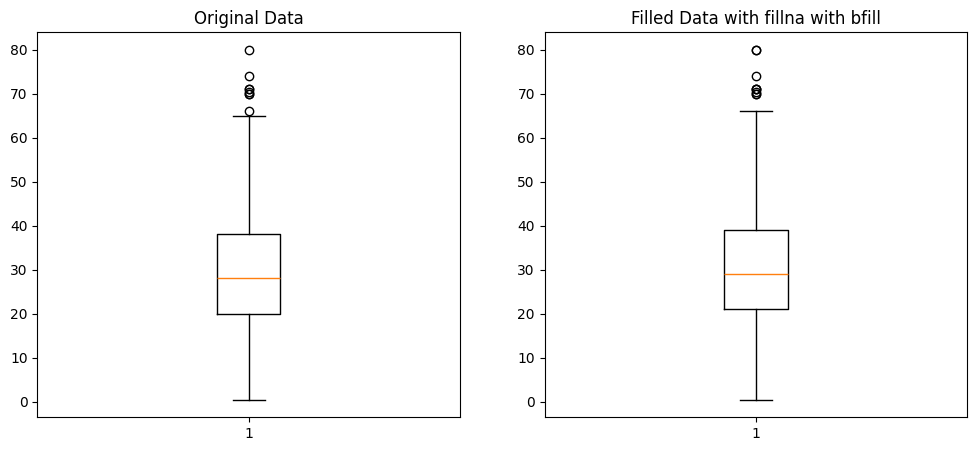

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].boxplot(df["Age"].dropna())
ax[0].set_title("Original Data")    

ax[1].boxplot(df_tmp["Age"])
ax[1].set_title("Filled Data with fillna with bfill")

Text(0.5, 1.0, 'Filled Data with fillna with bfill')

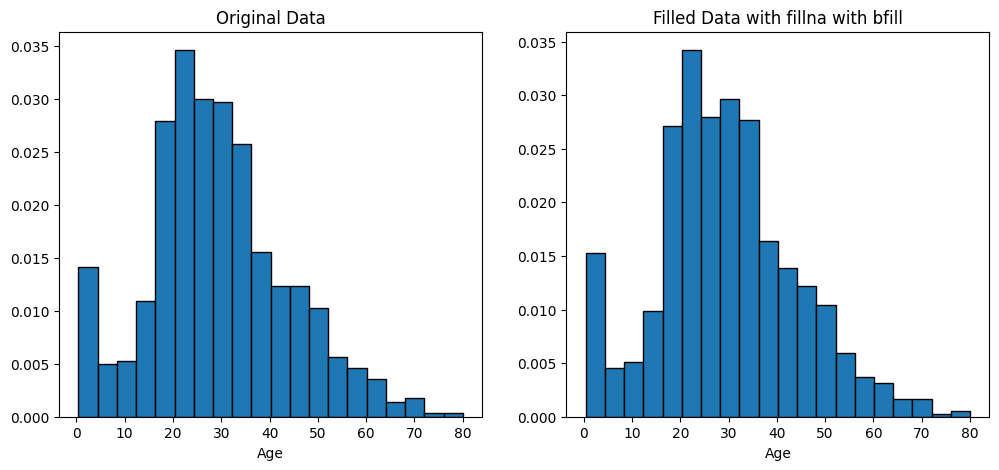

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(df["Age"], bins=20, density=True, edgecolor="black" )
ax[0].set_xlabel("Age")
ax[0].set_title("Original Data")

ax[1].hist(df_tmp["Age"], bins=20, density=True, edgecolor="black" )
ax[1].set_xlabel("Age")
ax[1].set_title("Filled Data with fillna with bfill")

Text(0.5, 1.0, 'Filled Data with fillna with ffill')

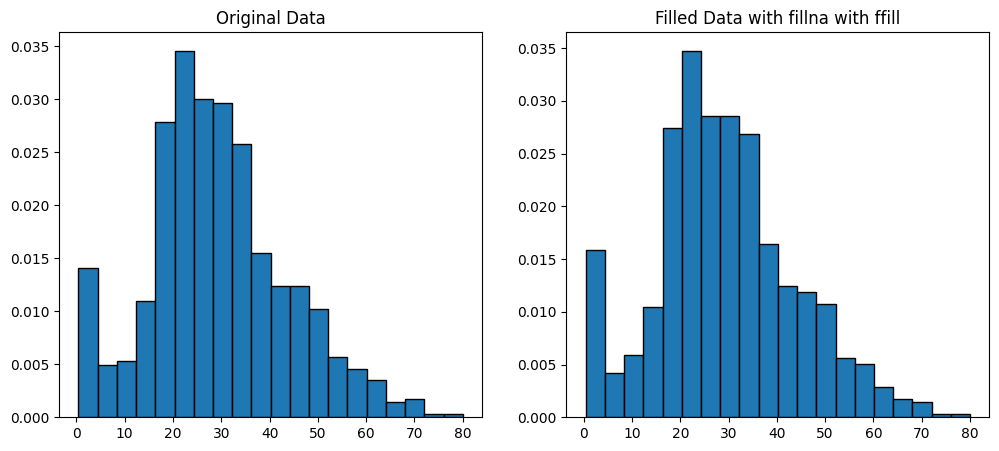

In [87]:
df_tmp = df.copy()
df_tmp["Age"] = df_tmp["Age"].ffill()
df_tmp.head(10)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(df["Age"].dropna(), bins=20, density=True, edgecolor="black")
ax[0].set_title("Original Data")    

ax[1].hist(df_tmp["Age"], bins=20, density=True, edgecolor="black")
ax[1].set_title("Filled Data with fillna with ffill")

<Axes: xlabel='Age', ylabel='Density'>

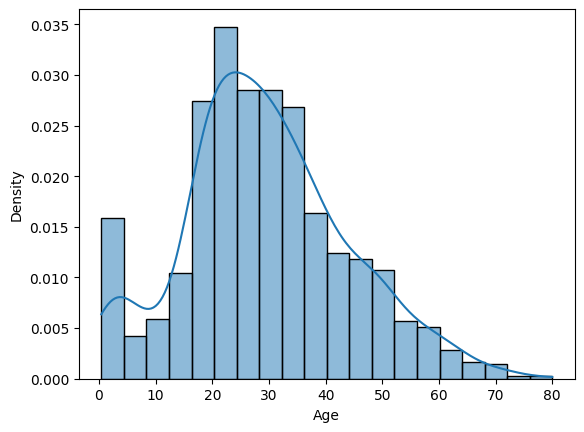

In [99]:
import seaborn as sns

df["Age"] = df["Age"].ffill().bfill()

# df["Age"].hist(bins=20, density=True, edgecolor="black")
# sns.kdeplot(df["Age"], fill=True)
sns.histplot(
    df["Age"],
    bins=20,
    kde=True,
    stat="density",
    edgecolor="black",
    fill=True
)

In [100]:
df.to_csv(Path.cwd() / "data" / "titanic_clean.csv", index=False)